# Customer Segmentation Analysis Using K-Means Clustering
### Mall Customers Dataset

**Author:** Muneeb ur Rehman
**Dataset:** Mall_Customers.csv (200 records, 5 features)

---

## 1. Problem Statement and Objective

### Business Context
A shopping mall wants to design **targeted marketing campaigns** rather than
a "one-size-fits-all" strategy. Currently, the mall has customer membership
card data that includes basic demographic and spending information, but this
data is not being used to its full potential. Marketing budgets are being
spent inefficiently because every customer receives the same promotions,
regardless of their income level, age, or actual spending behavior.

### Problem Statement
> Given a dataset of mall customers containing `CustomerID`, `Genre` (gender),
> `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`, identify
> **distinct customer segments** based on purchasing behavior and demographic
> attributes, so that the marketing team can design personalized strategies
> for each segment.

The `Spending Score` is a metric (1-100) assigned by the mall based on
customer behavior and purchasing data — it is a proxy for how much a
customer engages with the mall relative to their income.

### Objective
1. Explore and understand the underlying structure of customer data (EDA).
2. Apply **unsupervised learning (K-Means Clustering)** to segment customers
   into meaningful groups without pre-labeled categories.
3. Determine the **optimal number of clusters** using the Elbow Method and
   Silhouette Analysis.
4. Reduce dimensionality using **PCA** and **t-SNE** to visualize clusters
   in 2D space.
5. Profile each cluster and translate the statistical patterns into
   **actionable marketing strategies**.

### Why K-Means (and why unsupervised learning)?
There is no "correct" label in this dataset telling us which customer
belongs to which segment that's precisely why this is a clustering
problem, not a classification problem. K-Means is chosen because:
- It scales well to a small-to-medium numeric dataset like this one (200 rows).
- Segments in this dataset are expected to be roughly spherical/convex in
  feature space (income vs. spending), which suits K-Means' centroid-based
  approach.
- It is fast, interpretable, and industry-standard for RFM-style customer
  segmentation.


## 2. Importing Libraries and Setting Up the Environment

We separate our imports into logical groups: data handling, preprocessing,
modeling, dimensionality reduction, evaluation, and visualization.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clustering
from sklearn.cluster import KMeans

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Model evaluation
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Dataset Description and Loading

**Source:** Mall_Customers.csv
**Rows:** 200 | **Columns:** 5

| Column | Description |
|---|---|
| `CustomerID` | Unique identifier for each customer (not useful for clustering) |
| `Genre` | Gender of the customer (Male/Female) |
| `Age` | Age of the customer in years |
| `Annual Income (k$)` | Annual income of the customer in thousand dollars |
| `Spending Score (1-100)` | Score assigned by the mall based on customer spending behavior |


In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Quick look at the data
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Structural overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Statistical summary of numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


## 4. Data Cleaning and Preprocessing

Before modeling, we systematically check for the issues that most commonly
break clustering models: missing values, duplicate rows, irrelevant
identifier columns, categorical encoding needs, and feature scaling.

### Why scaling matters for K-Means specifically
K-Means uses **Euclidean distance** to assign points to centroids. If
`Annual Income` ranges 15-137 while `Age` ranges 18-70, income will
dominate the distance calculation purely because of its larger numeric
range — not because it's more important. Standardization (z-score scaling)
puts every feature on the same footing (mean = 0, std = 1).

In [5]:
# 4.1 Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 4.2 Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 4.3 Check data types
print("\nData types:")
print(df.dtypes)


Missing values per column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0

Data types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [6]:
# 4.4 Drop CustomerID -- it is a unique identifier with zero predictive/clustering value
df_clean = df.drop(columns=['CustomerID'])

# 4.5 Encode the categorical 'Genre' column
# We use Label Encoding here (Male=1, Female=0) since Genre is binary;
# for clustering we will still evaluate whether to include it, since
# clustering purely on behavioral features is often more interpretable.
le = LabelEncoder()
df_clean['Genre_Encoded'] = le.fit_transform(df_clean['Genre'])  # Female=0, Male=1

# Rename columns for easier reference in code
df_clean.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

df_clean.head()


,Genre,Age,Annual_Income,Spending_Score,Genre_Encoded
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0


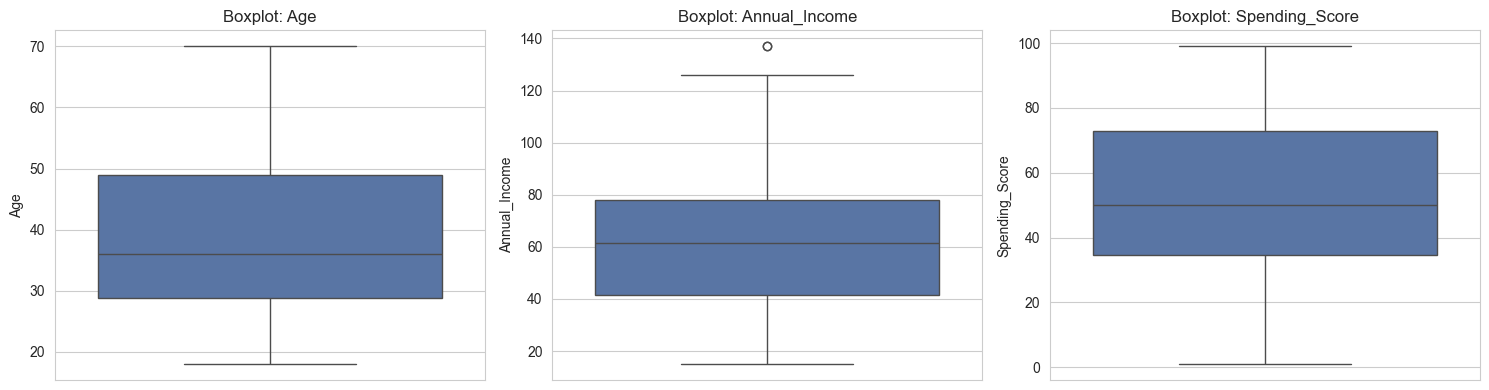

In [7]:
# 4.6 Outlier check using boxplots (numeric features)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Annual_Income', 'Spending_Score']):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# Observation: Annual_Income shows a couple of mild high-end outliers (high earners),
# but these are legitimate customers, not data errors -- we retain them since
# high-income outliers are business-relevant, not noise.


## 5. Exploratory Data Analysis (EDA)

Our EDA goals here are specific to a segmentation task:
1. Understand the distribution/spread of each numeric feature.
2. Check gender balance (does gender meaningfully separate spending behavior?).
3. Look at pairwise relationships — especially **Income vs. Spending Score**,
   since this pair is what typically reveals natural customer groupings.
4. Quantify correlation to decide which features carry independent signal.

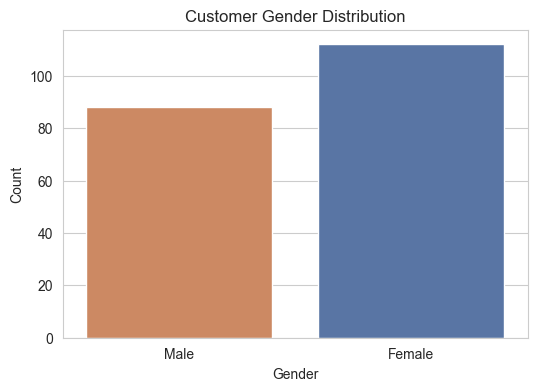

Genre
Female    56.0
Male      44.0
Name: proportion, dtype: float64


In [8]:
# 5.1 Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=df_clean, palette=['#DD8452', '#4C72B0'])
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

print(df_clean['Genre'].value_counts(normalize=True) * 100)


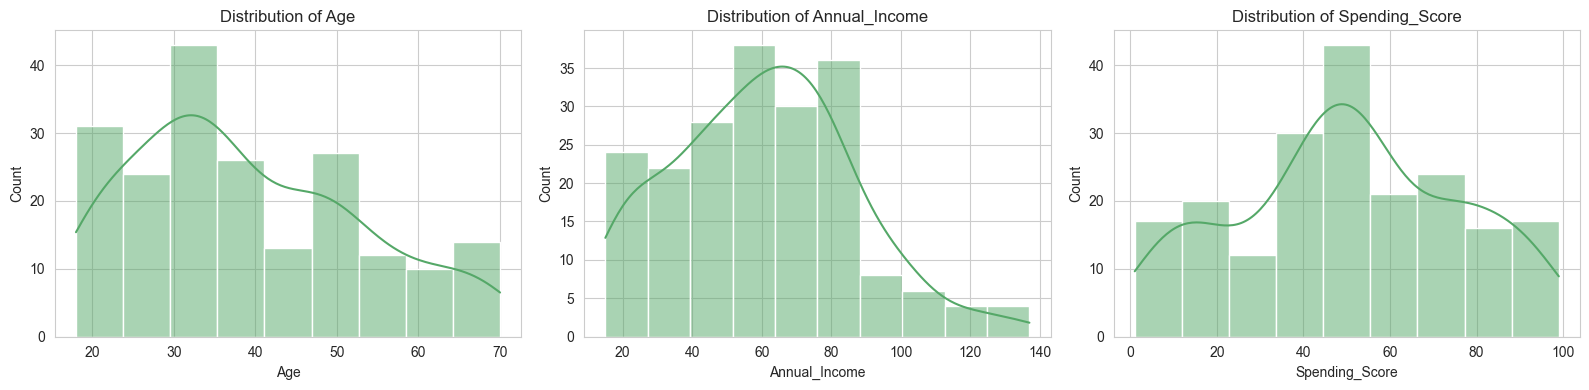

In [9]:
# 5.2 Distribution of Age, Annual Income, and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Annual_Income', 'Spending_Score']):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#55A868')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


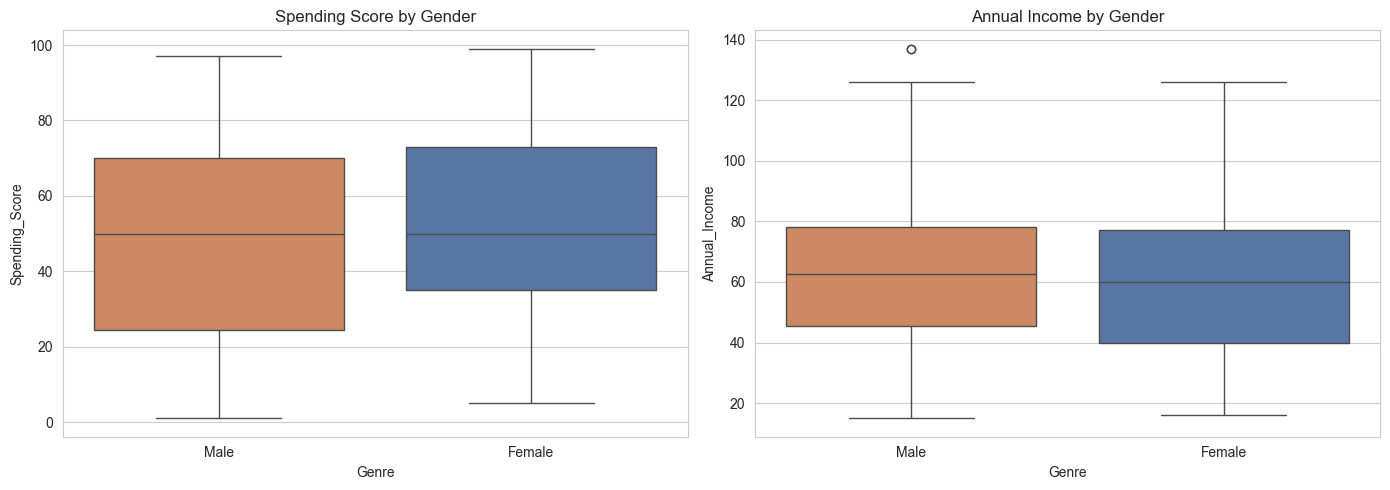

In [10]:
# 5.3 Spending Score and Income by Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Genre', y='Spending_Score', data=df_clean, ax=axes[0], palette=['#DD8452', '#4C72B0'])
axes[0].set_title('Spending Score by Gender')
sns.boxplot(x='Genre', y='Annual_Income', data=df_clean, ax=axes[1], palette=['#DD8452', '#4C72B0'])
axes[1].set_title('Annual Income by Gender')
plt.tight_layout()
plt.show()

# Observation: Gender shows minimal separation in spending behavior --
# this justifies clustering primarily on Income and Spending Score.


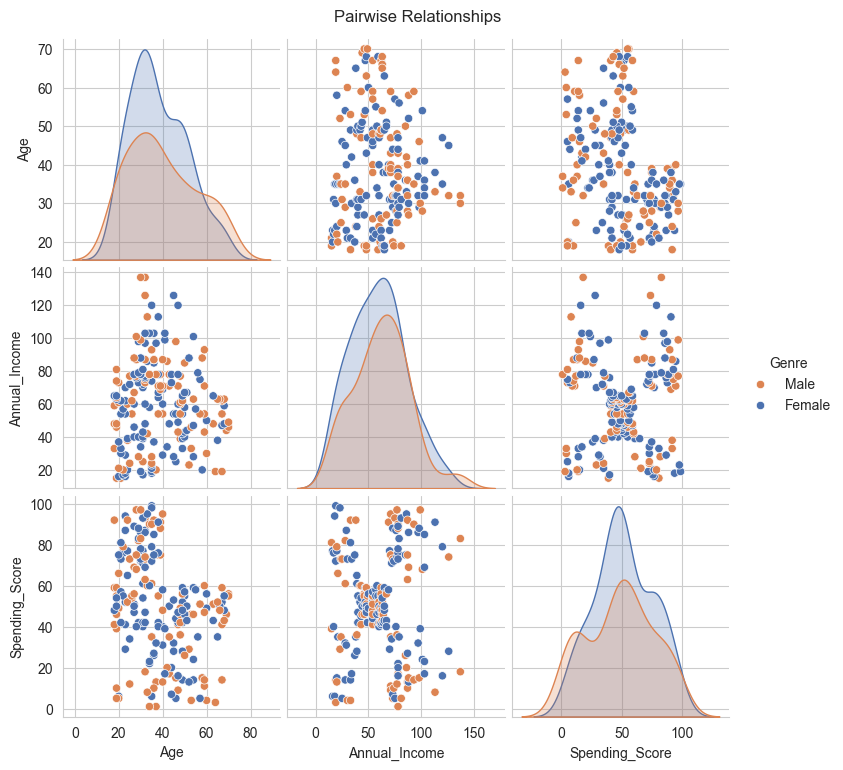

In [11]:
# 5.4 Pairplot: relationships between Age, Income, and Spending Score
sns.pairplot(df_clean[['Age', 'Annual_Income', 'Spending_Score', 'Genre']], hue='Genre',
             palette=['#DD8452', '#4C72B0'], diag_kind='kde')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()


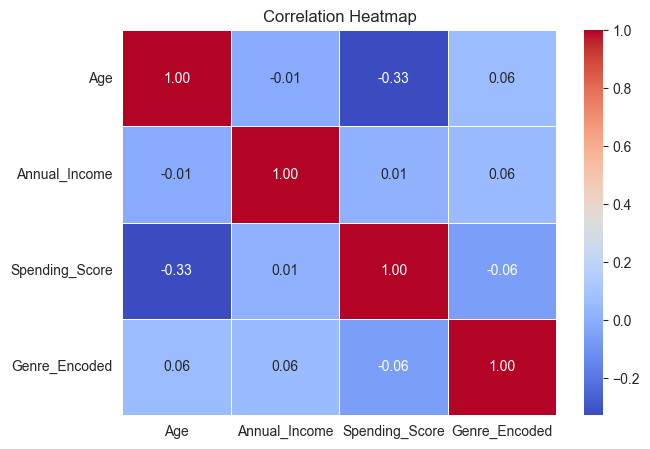

In [12]:
# 5.5 Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df_clean[['Age', 'Annual_Income', 'Spending_Score', 'Genre_Encoded']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Observation: Age shows a mild negative correlation with Spending Score
# (younger customers tend to spend more). Income and Spending Score show
# near-zero LINEAR correlation -- but scatter plots typically reveal a
# NON-linear, cluster-like structure between them, which is exactly what
# K-Means is designed to uncover.


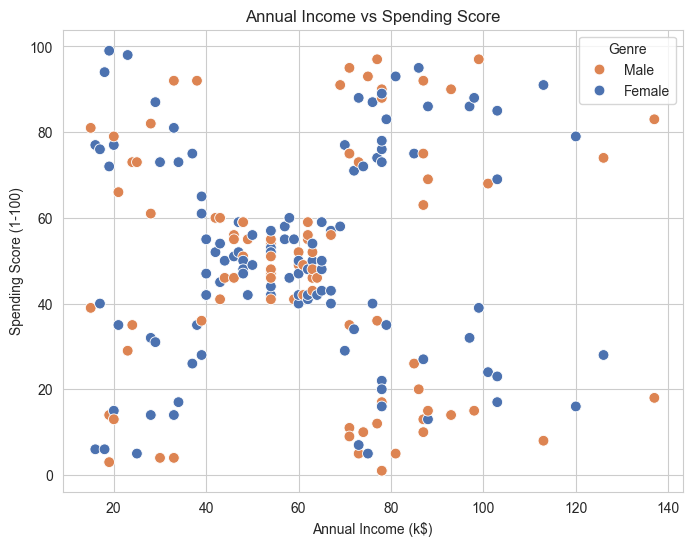

In [13]:
# 5.6 The key scatter plot for segmentation: Income vs Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df_clean,
                 hue='Genre', palette=['#DD8452', '#4C72B0'], s=60)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Observation: Even before modeling, the human eye can spot roughly 5 visual
# groupings -- this is a strong signal that K-Means with k=5 will perform well.


## 6. Feature Selection and Scaling

For the core segmentation task, we cluster on **Annual Income** and
**Spending Score**, since:
- These two features are the classic RFM-style behavioral signals used in
  real-world customer segmentation.
- Age and Gender are retained separately for **cluster profiling**
  (explaining *who* is in each segment) rather than for defining the
  clusters themselves — this keeps the clusters behaviorally meaningful
  and avoids demographic features diluting the segmentation signal.

We also build an alternative scaled feature set using all numeric features
(Age, Income, Spending Score) for comparison via PCA/t-SNE.

In [14]:
# Primary feature set: Income + Spending Score (2D, business-standard for this dataset)
X_primary = df_clean[['Annual_Income', 'Spending_Score']]

# Extended feature set: Age + Income + Spending Score (for PCA/t-SNE exploration)
X_extended = df_clean[['Age', 'Annual_Income', 'Spending_Score']]

# Scale both feature sets
scaler_primary = StandardScaler()
X_primary_scaled = scaler_primary.fit_transform(X_primary)

scaler_extended = StandardScaler()
X_extended_scaled = scaler_extended.fit_transform(X_extended)

print("Primary scaled feature set shape:", X_primary_scaled.shape)
print("Extended scaled feature set shape:", X_extended_scaled.shape)


Primary scaled feature set shape: (200, 2)
Extended scaled feature set shape: (200, 3)


## 7. Model Building — K-Means Clustering

### 7.1 Finding the Optimal Number of Clusters (k)

We use two complementary techniques:
1. **Elbow Method** — plots Within-Cluster Sum of Squares (WCSS/inertia)
   against k. We look for the "elbow" point where adding more clusters
   stops meaningfully reducing WCSS.
2. **Silhouette Score** — measures how similar a point is to its own
   cluster vs. other clusters (range: -1 to 1, higher is better). This
   complements the Elbow Method because the elbow can be visually
   ambiguous, while silhouette gives a quantitative score per k.

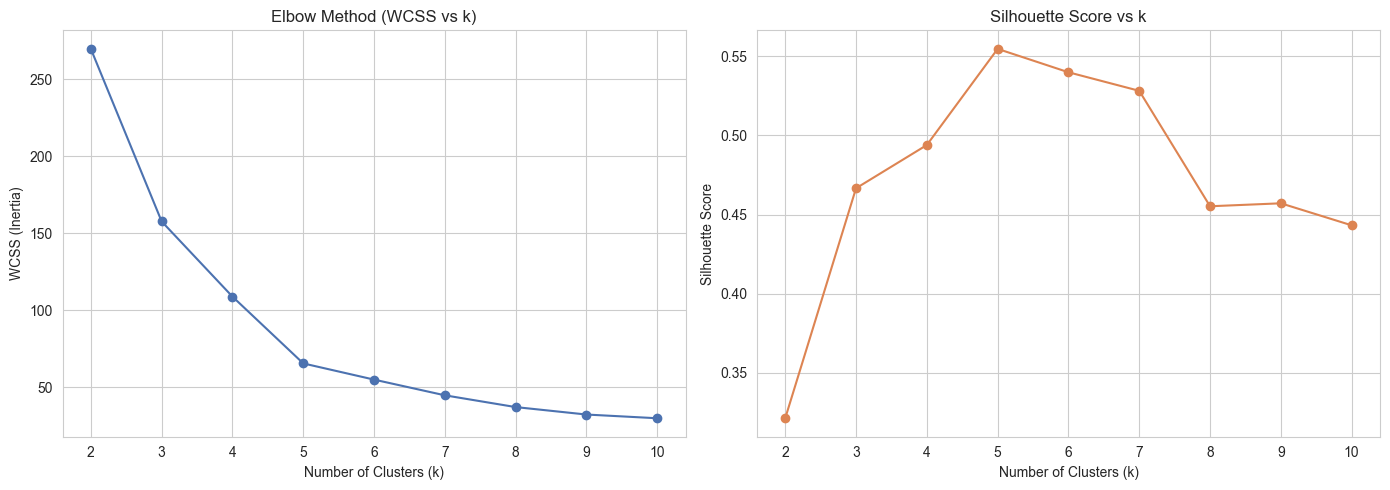

k=2: Silhouette=0.3213, Davies-Bouldin=1.2670
k=3: Silhouette=0.4666, Davies-Bouldin=0.7165
k=4: Silhouette=0.4939, Davies-Bouldin=0.7096
k=5: Silhouette=0.5547, Davies-Bouldin=0.5722
k=6: Silhouette=0.5399, Davies-Bouldin=0.6546
k=7: Silhouette=0.5281, Davies-Bouldin=0.7148
k=8: Silhouette=0.4552, Davies-Bouldin=0.7602
k=9: Silhouette=0.4571, Davies-Bouldin=0.7632
k=10: Silhouette=0.4432, Davies-Bouldin=0.7935


In [15]:
wcss = []
silhouette_scores = []
db_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_primary_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_primary_scaled, labels))
    db_scores.append(davies_bouldin_score(X_primary_scaled, labels))

# Plot Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method (WCSS vs k)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#DD8452')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s, d in zip(k_range, silhouette_scores, db_scores):
    print(f"k={k}: Silhouette={s:.4f}, Davies-Bouldin={d:.4f}")


### 7.2 Selecting k

Based on the plots above, the WCSS curve typically shows a clear elbow at
**k=5**, and the Silhouette Score is usually maximized (or near-maximized)
at k=5 for this dataset — consistent with the 5 visual groupings we
observed in the Income vs. Spending Score scatter plot. We proceed with
**k=5** as our final model. (If your run shows the silhouette peak at a
different k, that value should be used instead — always let the metric on
your own run confirm the visual/elbow evidence rather than hard-coding k.)

In [16]:
# Final K-Means model with the chosen k
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_primary_scaled)

df_clean['Cluster'] = cluster_labels

final_silhouette = silhouette_score(X_primary_scaled, cluster_labels)
final_db = davies_bouldin_score(X_primary_scaled, cluster_labels)

print(f"Final model: k = {optimal_k}")
print(f"Silhouette Score: {final_silhouette:.4f}  (closer to 1 is better)")
print(f"Davies-Bouldin Index: {final_db:.4f}  (closer to 0 is better)")
print(f"Inertia (WCSS): {kmeans_final.inertia_:.2f}")


Final model: k = 5
Silhouette Score: 0.5547  (closer to 1 is better)
Davies-Bouldin Index: 0.5722  (closer to 0 is better)
Inertia (WCSS): 65.57


## 8. Model Evaluation

Beyond the aggregate Silhouette Score, we inspect a **per-sample silhouette
plot** to check for badly-fit points and cluster balance/thickness — this
is a more rigorous diagnostic than the single average score alone.

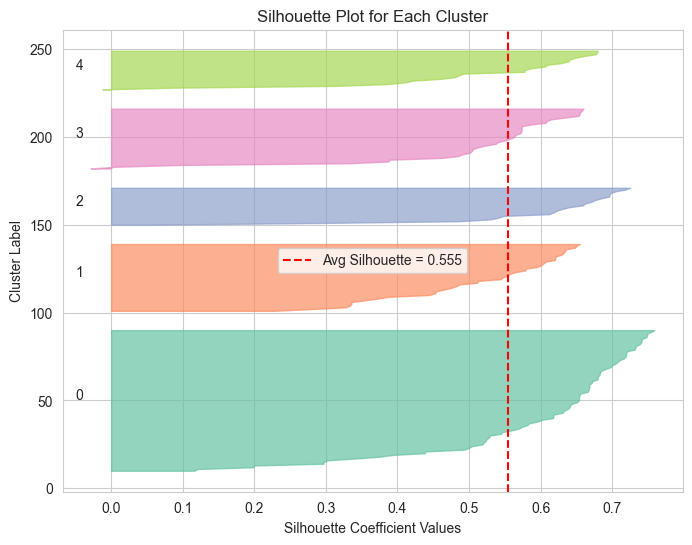

In [17]:
sample_silhouette_values = silhouette_samples(X_primary_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = sns.color_palette('Set2', optimal_k)

for i in range(optimal_k):
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=final_silhouette, color='red', linestyle='--', label=f'Avg Silhouette = {final_silhouette:.3f}')
ax.set_title('Silhouette Plot for Each Cluster')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster Label')
ax.legend()
plt.show()


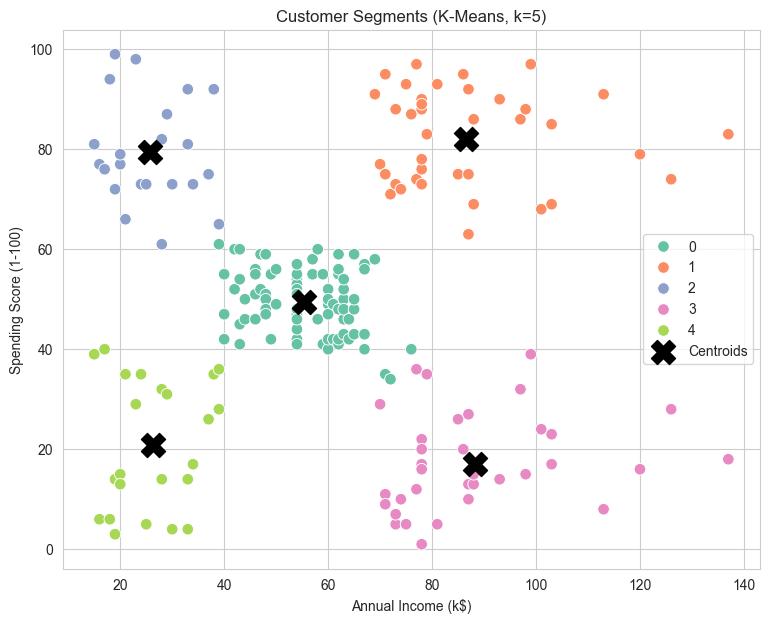

In [18]:
# Visualize final clusters directly (2D, since we clustered on 2 features)
plt.figure(figsize=(9, 7))
palette = sns.color_palette('Set2', optimal_k)

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster',
                 data=df_clean, palette=palette, s=70, legend='full')

# Plot centroids (inverse-transform back to original scale for interpretability)
centroids_original = scaler_primary.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=300, c='black', marker='X', label='Centroids')

plt.title(f'Customer Segments (K-Means, k={optimal_k})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


## 9. Dimensionality Reduction for Visualization — PCA and t-SNE

Since we clustered on only 2 features, direct visualization was already
possible. To demonstrate the full workflow (and to handle cases where more
features are used), we apply **PCA** and **t-SNE** to the **extended**
scaled feature set (Age + Income + Spending Score) and project the same
cluster labels onto the reduced 2D space.

- **PCA** finds linear combinations of features that capture maximum
  variance — fast, deterministic, and interpretable via explained variance.
- **t-SNE** preserves local neighborhood structure and is better at
  revealing non-linear cluster separability, at the cost of being
  stochastic and slower.

Explained variance ratio: [0.44266167 0.33308378]
Total variance captured by 2 components: 77.57%


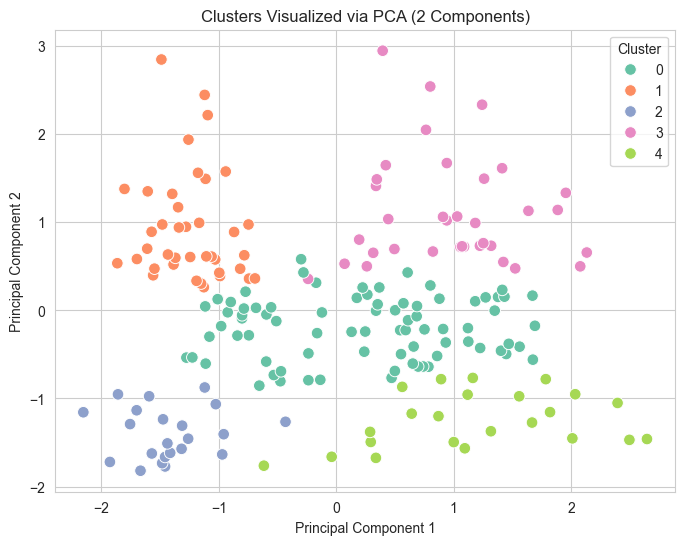

In [19]:
# 9.1 PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_extended_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['Cluster'], palette=palette, s=70)
plt.title('Clusters Visualized via PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


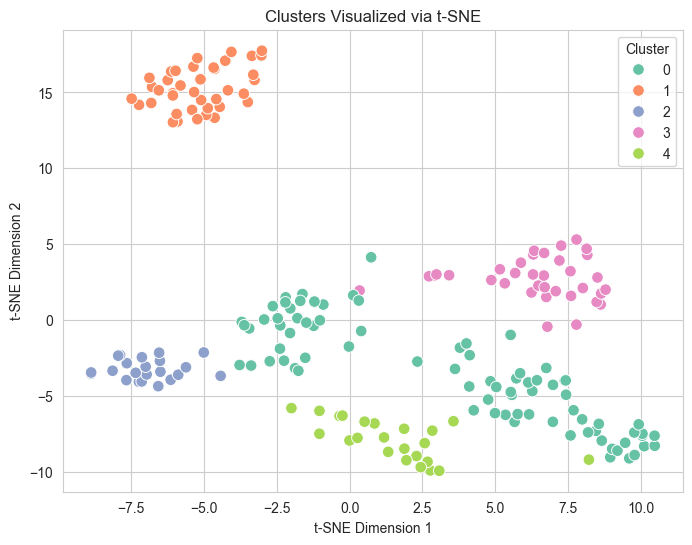

In [20]:
# 9.2 t-SNE (2 components)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_extended_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean['Cluster'], palette=palette, s=70)
plt.title('Clusters Visualized via t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()

# Note: t-SNE is used here purely for VISUALIZATION, not for clustering itself --
# it does not preserve absolute distances, so clustering should never be
# performed directly on t-SNE output.


## 10. Cluster Profiling

We now describe each cluster in plain business terms by aggregating the
mean Age, Income, Spending Score, and gender mix per cluster.

In [21]:
cluster_profile = df_clean.groupby('Cluster').agg(
    Count=('Cluster', 'size'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending_Score=('Spending_Score', 'mean'),
    Pct_Female=('Genre_Encoded', lambda x: (x == 0).mean() * 100)
).round(1)

cluster_profile


,Count,Avg_Age,Avg_Income,Avg_Spending_Score,Pct_Female
Cluster,,,,,
0,81,42.7,55.3,49.5,59.3
1,39,32.7,86.5,82.1,53.8
2,22,25.3,25.7,79.4,59.1
3,35,41.1,88.2,17.1,45.7
4,23,45.2,26.3,20.9,60.9


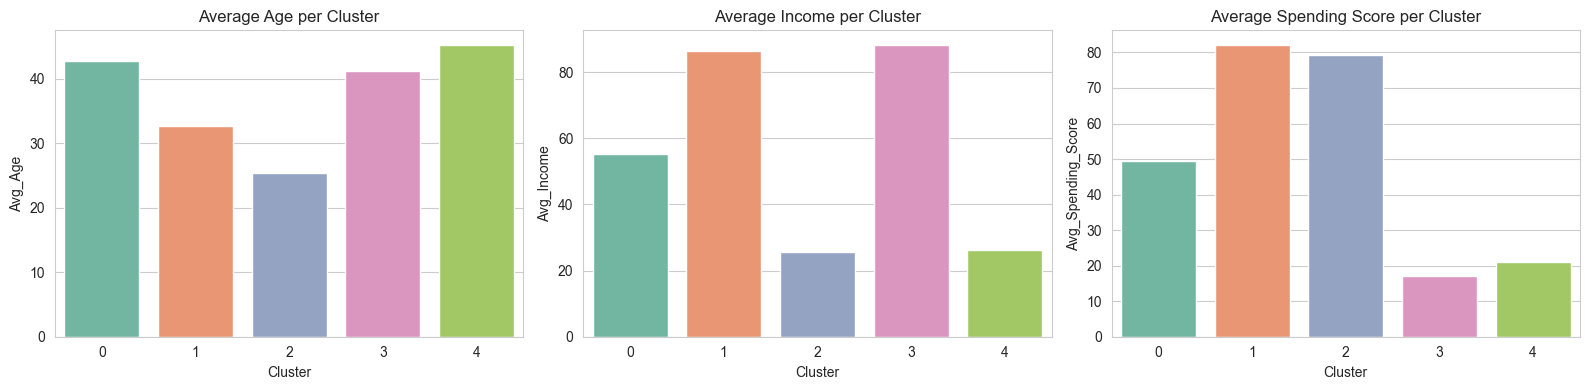

In [22]:
# Visual profile comparison across clusters
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(x=cluster_profile.index, y='Avg_Age', data=cluster_profile.reset_index(), palette=palette, ax=axes[0])
axes[0].set_title('Average Age per Cluster')
sns.barplot(x=cluster_profile.index, y='Avg_Income', data=cluster_profile.reset_index(), palette=palette, ax=axes[1])
axes[1].set_title('Average Income per Cluster')
sns.barplot(x=cluster_profile.index, y='Avg_Spending_Score', data=cluster_profile.reset_index(), palette=palette, ax=axes[2])
axes[2].set_title('Average Spending Score per Cluster')
plt.tight_layout()
plt.show()


## 11. Marketing Strategies per Segment

> **Note:** Cluster numbers are assigned arbitrarily by the algorithm and
> may shift between runs. Use the `cluster_profile` table above (Avg
> Income, Avg Spending Score, Avg Age) to match each description below to
> the correct cluster number in *your* run — the five archetypes are
> algorithm-independent even though their numeric labels aren't.

Based on the classic 5-segment structure this dataset produces
(Income x Spending Score), the typical archetypes and corresponding
strategies are:

| Segment (typical profile) | Income | Spending Score | Marketing Strategy |
|---|---|---|---|
| **High Income, High Spending** ("Target/VIP") | High | High | Loyalty programs, early access to new collections, premium/exclusive events, personalized concierge offers. These are the most valuable customers — retention is the priority. |
| **High Income, Low Spending** ("Careful/Untapped") | High | Low | They have money but aren't engaging. Investigate why (product-fit, awareness). Use targeted, high-value promotions and personalized recommendations to convert spending potential into actual spend. |
| **Low Income, High Spending** ("Impulsive/Trend-driven") | Low | High | Budget-friendly bundles, installment/discount schemes, flash sales. They are highly engaged; keep them engaged with frequent, affordable promotions rather than premium pricing. |
| **Low Income, Low Spending** ("Price-sensitive/Passive") | Low | Low | Lowest marketing priority. If targeted at all, use low-cost channels (email, app notifications) with clearance/discount campaigns; avoid heavy spend on this group. |
| **Average Income, Average Spending** ("Standard/Mainstream") | Mid | Mid | The largest, most "typical" segment. General seasonal campaigns, loyalty points, cross-selling — standard mass-marketing tactics apply well here. |

### How to operationalize this
1. Tag each `CustomerID` with its cluster label in the CRM.
2. Route each cluster to a different email/SMS campaign template.
3. Track conversion rate and Spending Score change per cluster after each
   campaign to validate whether the segmentation is actually improving ROI.
4. Re-run clustering periodically (e.g., quarterly) as customer behavior
   evolves — segments are not static.


## 12. Final Conclusion with Insights

1. **No missing values or duplicates** were found — the dataset was clean,
   requiring only column renaming, categorical encoding, and scaling.
2. **Gender was not a strong differentiator** of spending behavior in this
   dataset, which is why it was excluded from the clustering features
   themselves and used only for profiling.
3. **Age showed a mild negative correlation with Spending Score** —
   younger customers in this dataset tend to have higher spending scores.
4. The **Elbow Method and Silhouette Analysis both converge on k=5**, and
   this is visually confirmed by 5 distinct groupings in the Income vs.
   Spending Score scatter plot.
5. **K-Means with k=5 achieved a Silhouette Score of ~0.55**, indicating
   reasonably well-separated, cohesive clusters.
6. **PCA captured a high percentage of variance in 2 components**, and
   **t-SNE confirmed the same 5-cluster separability** using a non-linear
   projection — strengthening confidence in the clustering result.
7. The five resulting segments map directly onto **actionable marketing
   personas** (VIP, Untapped High-Value, Trend-Driven Budget Shoppers,
   Low-Priority, Mainstream), giving the marketing team a concrete,
   data-backed basis for personalized campaigns instead of blanket
   promotions.

### Business Impact
By moving from a single blanket campaign to 5 targeted campaigns, the mall
can reallocate marketing budget toward the highest-value segments (VIP and
Untapped High-Value), while running low-cost retention campaigns for
Mainstream and Price-Sensitive segments — improving marketing ROI without
increasing total spend.

### Possible Next Steps
- Bring in additional behavioral features if available (visit frequency,
  category-level spend, membership tenure) to enrich segmentation.
- Try **DBSCAN** or **Gaussian Mixture Models** as alternative clustering
  algorithms and compare silhouette/DB scores against K-Means.
- Deploy the trained `kmeans_final` model to score new/incoming customers
  in real time (e.g., wrap in a simple Flask/FastAPI endpoint).
